In [1]:
import pickle
import numpy as np
import numpy.typing as npt
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as path_effects
import main
from forward_models import SOIL_DEPTH_MM, INORGANIC_N_MODEL_DT_DAYS
from dataclasses import dataclass, field
import inspect
from typing import Dict, List

In [11]:
CONTROL_TIMESTEP_DAYS = 3
NUM_CONTROL_STEPS = int(36 / CONTROL_TIMESTEP_DAYS)

In [12]:
@dataclass
class RolloutGraphData:
    n_accumulation_trajectories_by_penalty: Dict[float, npt.NDArray[np.float64]]
    fertilizer_adds_by_penalty: Dict[float, npt.NDArray[np.float64]]
    soil_condition_risks: List[float]

In [13]:
with open(str(CONTROL_TIMESTEP_DAYS) + "_days_rainfall_317_graph.pkl", "rb") as f:
    rollout_graph_data = pickle.load(f)
rollout_graph_data

RolloutGraphData(n_accumulation_trajectories_by_penalty={np.float64(0.0): array([ 0.19451659,  0.38850867,  0.58197757, ..., 87.36808874,
       87.36939213, 87.37069462], shape=(2592,)), np.float64(0.20126710688876742): array([ 0.22000938,  0.43938529,  0.65812958, ..., 83.53993197,
       83.54118208, 83.54243166], shape=(2592,)), np.float64(0.40253421377753484): array([ 0.19412771,  0.38769664,  0.58070842, ..., 69.68777332,
       69.68902343, 69.69027301], shape=(2592,))}, fertilizer_adds_by_penalty={np.float64(0.0): array([69.655     ,  4.57079339,  0.        ,  0.        ,  5.13365485,
        0.        ,  0.        ,  5.25072729,  0.        ,  0.        ,
        0.        ,  0.        ]), np.float64(0.20126710688876742): array([75.928     ,  4.84249695,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ]), np.float64(0.40253421377753484): array([66.96,  0.  ,  0.  ,  0.  ,  0.  ,  0.  ,

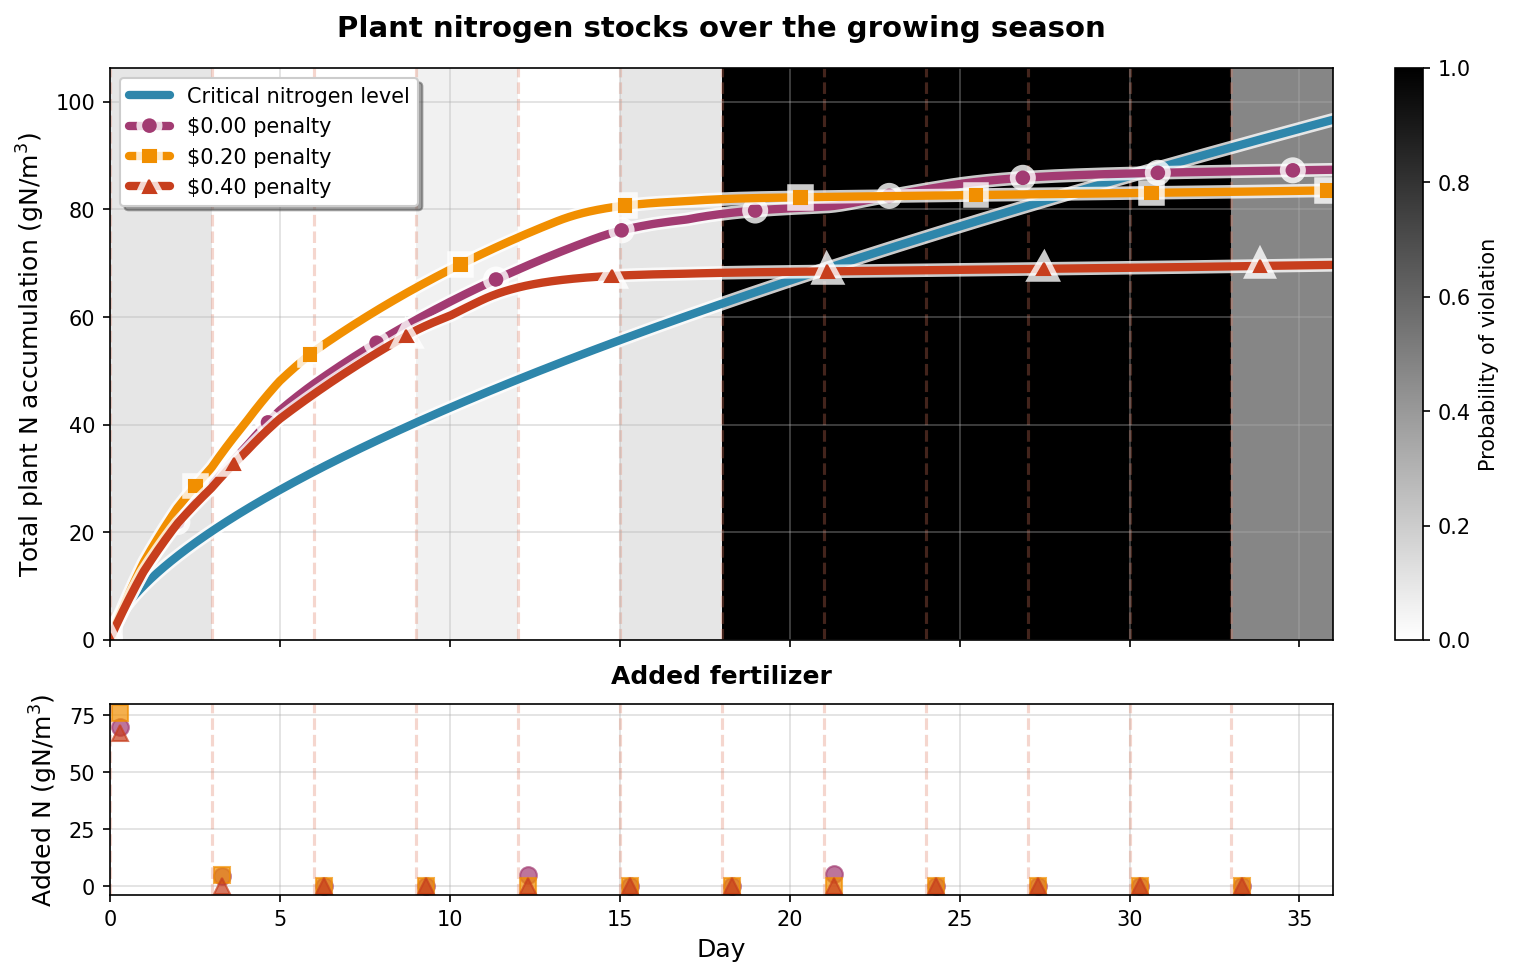

In [14]:
# Modern color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4B51']
line_styles = ['--', '-.', ':']
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p']

penalties = list(rollout_graph_data.n_accumulation_trajectories_by_penalty.keys())
fig, (ax, lower_ax) = plt.subplots(2, 1, sharex=True, height_ratios=[3, 1], figsize=[10, 6.4], layout='constrained', dpi=150)

ax.set_title("Plant nitrogen stocks over the growing season", fontsize=14, fontweight='bold', pad=15)
x_series = np.arange(len(rollout_graph_data.n_accumulation_trajectories_by_penalty[penalties[0]])) * INORGANIC_N_MODEL_DT_DAYS

# Draw colored blocks FIRST (behind everything else)
cmap = mpl.colormaps['binary']
n_crit = main.biomass_g_per_m2_to_critical_nitrogen_gN_per_m2(main.day_to_biomass_g_per_m2(x_series)) / (main.SOIL_DEPTH_MM / 1000.)
y_max = np.max(n_crit)
for trajectory in rollout_graph_data.n_accumulation_trajectories_by_penalty.values():
    y_max = max(y_max, np.max(trajectory))
y_max *= 1.1
x_max = NUM_CONTROL_STEPS * CONTROL_TIMESTEP_DAYS

for i in range(NUM_CONTROL_STEPS):
    day = i * CONTROL_TIMESTEP_DAYS
    ax.fill([day, day, day + CONTROL_TIMESTEP_DAYS, day + CONTROL_TIMESTEP_DAYS], [0, y_max, y_max, 0], color=cmap(rollout_graph_data.soil_condition_risks[i]), zorder=0, linewidth=0)

# Now draw lines on top with white outlines for visibility
ax.plot(x_series, n_crit, label="Critical nitrogen level", color=colors[0], linewidth=4, alpha=1, zorder=2, solid_capstyle='round', path_effects=[path_effects.Stroke(linewidth=6.5, foreground='white', alpha=0.8), path_effects.Normal()])
trajectories_by_penalty = {}
for idx, (leaching_penalty_USD, trajectory) in enumerate(rollout_graph_data.n_accumulation_trajectories_by_penalty.items()):
    ax.plot(x_series,
            trajectory, 
            label="${:04.2f} penalty".format(leaching_penalty_USD), 
            color=colors[1 + idx],
            # linestyle=line_styles[idx],
            marker=markers[idx],
            markersize=6,
            markevery=0.1 + 0.03 * idx,
            linewidth=4, 
            alpha=1, 
            zorder=2, 
            solid_capstyle='round', 
            path_effects=[path_effects.Stroke(linewidth=6.5, foreground='white', alpha=0.8), path_effects.Normal()])

ax.vlines(np.linspace(0, x_max, NUM_CONTROL_STEPS, endpoint=False), 0, y_max, color='#E07A5F', alpha=0.3, linestyles="dashed", linewidth=1.5, zorder=1)

ax.set_ylabel("Total plant N accumulation (gN/$\\text{m}^3$)", fontsize=12)
ax.set_xlim(0, x_max)
ax.set_ylim(0, y_max)

cbar = fig.colorbar(mpl.cm.ScalarMappable(cmap=cmap), ax=ax)
cbar.set_label('Probability of violation', fontsize=10)

ax.legend(loc="upper left", frameon=True, shadow=True, fontsize=10)
ax.grid(True, alpha=0.4, zorder=1)

# Lower subplot with modern styling
for idx, fertilizer_adds in enumerate(rollout_graph_data.fertilizer_adds_by_penalty.values()):
    lower_ax.plot(np.linspace(0, x_max, len(fertilizer_adds) + 1)[:-1] + 0.3, fertilizer_adds, markers[idx],
                     color=colors[idx + 1],
                     alpha=0.7,
                     markersize=8)
lower_ax.set_title("Added fertilizer", fontsize=12, fontweight='bold', pad=10)
lower_ax.set_xlabel("Day", fontsize=12)
lower_ax.set_ylabel("Added N (gN/$\\text{m}^3$)", fontsize=12)

for x in np.linspace(0, x_max, NUM_CONTROL_STEPS, endpoint=False):
    lower_ax.axvline(x, color='#E07A5F', alpha=0.3, linestyle="dashed", linewidth=1.5)

lower_ax.grid(True, alpha=0.4)

# fig.savefig("mixed_violating_trajectory.png", transparent=True, dpi=300, bbox_inches='tight')